# 01 - TESS Data Download
Downloads TESS light curves from the NASA ExoFOP TOI catalog.
Sequential downloads with multi-strategy fallback and retry logic.

## 1. Imports

In [12]:
import lightkurve as lk
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os, warnings, glob, time, collections
from tqdm import tqdm
warnings.filterwarnings("ignore")

print(f"lightkurve : {lk.__version__}")
print("All imports OK!")

lightkurve : 2.6.0
All imports OK!


## 2. Configuration

In [13]:
RAW_DIR     = "../data/raw/"
LABELED_DIR = "../data/labeled/"
os.makedirs(RAW_DIR,     exist_ok=True)
os.makedirs(LABELED_DIR, exist_ok=True)

N_PLANETS   = 40   # confirmed planets     (CP + KP)
N_EB        = 25   # eclipsing binaries    (TESS Disposition = EB)
N_FP        = 20   # other false positives (FP, non-EB)
N_PC        = 20   # planet candidates     (PC — labeled training class)
N_SCIENCE   = 20   # ambiguous candidates  (APC — unlabeled, for classification)
MAX_RETRIES = 3

print(f"planet={N_PLANETS}  EB={N_EB}  FP={N_FP}  PC={N_PC}  science={N_SCIENCE}")
print(f"RAW_DIR={RAW_DIR}   LABELED_DIR={LABELED_DIR}")


planet=40  EB=25  FP=20  PC=20  science=20
RAW_DIR=../data/raw/   LABELED_DIR=../data/labeled/


## 3. Load TOI Catalog

In [14]:
url    = "https://exofop.ipac.caltech.edu/tess/download_toi.php?sort=toi&output=csv"
toi_df = pd.read_csv(url)
toi_df["TIC ID"] = toi_df["TIC ID"].astype(str)

print(f"Total TOIs: {len(toi_df)}")
print(toi_df["TFOPWG Disposition"].value_counts())

Total TOIs: 8035
TFOPWG Disposition
PC     4879
FP     1244
CP      735
KP      592
APC     482
FA      100
Name: count, dtype: int64


## 4. Select Targets

In [15]:
cp_df = (toi_df[toi_df["TFOPWG Disposition"].isin(["CP", "KP"])]
         .drop_duplicates("TIC ID")
         .sample(frac=1, random_state=42)
         .head(N_PLANETS))

eb_df = (toi_df[toi_df["TESS Disposition"] == "EB"]
         .drop_duplicates("TIC ID")
         .sample(frac=1, random_state=42)
         .head(N_EB))

fp_df = (toi_df[
             (toi_df["TFOPWG Disposition"] == "FP") &
             (toi_df["TESS Disposition"]   != "EB")
         ]
         .drop_duplicates("TIC ID")
         .sample(frac=1, random_state=42)
         .head(N_FP))

pc_df = (toi_df[toi_df["TFOPWG Disposition"] == "PC"]
         .drop_duplicates("TIC ID")
         .sample(frac=1, random_state=42)
         .head(N_PC))

# APC = Ambiguous Planet Candidate — unlabeled science targets
apc_df = (toi_df[toi_df["TFOPWG Disposition"] == "APC"]
          .drop_duplicates("TIC ID")
          .sample(frac=1, random_state=99)
          .head(N_SCIENCE))

labeled_targets = (
    [(tic, "planet")           for tic in cp_df["TIC ID"]] +
    [(tic, "eclipsing_binary") for tic in eb_df["TIC ID"]] +
    [(tic, "false_positive")   for tic in fp_df["TIC ID"]] +
    [(tic, "planet_candidate") for tic in pc_df["TIC ID"]]
)
science_targets = apc_df["TIC ID"].tolist()

print("Label counts     :", dict(collections.Counter(l for _, l in labeled_targets)))
print("Science targets  :", len(science_targets))


Label counts     : {'planet': 40, 'eclipsing_binary': 25, 'false_positive': 20, 'planet_candidate': 20}
Science targets  : 20


## 5. Diagnostic - Test One Download
Run this cell first to confirm lightkurve can reach MAST.

In [16]:
TEST_TIC = cp_df["TIC ID"].iloc[0]
print(f"Testing TIC {TEST_TIC} ...")
try:
    sr = lk.search_lightcurve(f"TIC {TEST_TIC}", mission="TESS")
    print(f"  Results found : {len(sr)}")
    if len(sr) > 0:
        lc = sr[0].download()
        print(f"  Download OK   : {len(lc)} cadences")
        print("DIAGNOSTIC PASSED")
    else:
        print("No data found - check internet connection")
except Exception as e:
    print(f"DIAGNOSTIC FAILED: {type(e).__name__}: {e}")

Testing TIC 115524421 ...
  Results found : 30
  Download OK   : 16418 cadences
DIAGNOSTIC PASSED


## 6. Download Functions

In [17]:
# Strategies tried in order; stops at first that returns data.
# Many TOI targets only have FFI products (QLP/TESS-SPOC), not 2-min SPOC.
_STRATEGIES = [
    dict(exptime=120),          # 2-min SPOC targeted pixels
    dict(exptime=20),           # 20-sec SPOC
    dict(author="TESS-SPOC"),   # FFI SPOC pipeline
    dict(author="QLP"),         # MIT QLP (widest coverage)
    dict(author="TASOC"),       # TASOC pipeline
    dict(),                     # anything MAST has
]


def download_one(tic_id, save_dir):
    save_path = os.path.join(save_dir, f"TIC_{tic_id}.fits")
    if os.path.exists(save_path):
        return True, "cached"

    last_err = "no_data"
    for attempt in range(1, MAX_RETRIES + 1):
        for strategy in _STRATEGIES:
            try:
                sr = lk.search_lightcurve(
                    f"TIC {tic_id}", mission="TESS", **strategy
                )
                if len(sr) == 0:
                    continue
                lc = sr[0].download()
                lc.to_fits(save_path, overwrite=True)
                try:
                    sector = int(sr.table["sequence_number"][0])
                    author = str(sr.table["author"][0])
                    return True, f"sector_{sector} ({author})"
                except Exception:
                    return True, "downloaded"
            except Exception as e:
                last_err = f"{type(e).__name__}: {e}"
                continue
        if attempt < MAX_RETRIES:
            wait = 2 * attempt
            print(f"  TIC {tic_id} attempt {attempt} failed, retrying in {wait}s...")
            time.sleep(wait)
    return False, last_err


def batch_download(targets, save_dir):
    """targets: list of TIC strings OR list of (TIC, label) tuples."""
    if targets and isinstance(targets[0], str):
        pairs = [(t, None) for t in targets]
    else:
        pairs = list(targets)

    # Shuffle so planets and false_positives are interleaved.
    # If MAST rate-limits partway through, both classes still get some coverage.
    import random
    random.seed(42)
    random.shuffle(pairs)

    os.makedirs(save_dir, exist_ok=True)
    log = []
    for tic, label in tqdm(pairs, unit="star"):
        ok, info = download_one(tic, save_dir)
        tag = "[OK]  " if ok else "[FAIL]"
        print(f"{tag}  TIC {str(tic):<14}  label={str(label):<18}  {info}")
        log.append({"tic_id": tic, "label": label, "success": ok, "info": info})
        time.sleep(0.5)   # avoid MAST rate-limit
    return pd.DataFrame(log)



print("Download functions ready!")

Download functions ready!


## 7. Run Downloads

In [18]:
print("=" * 50)
print("LABELED DATA (planets + false positives)")
print("=" * 50)
label_df = batch_download(labeled_targets, LABELED_DIR)

label_df[label_df["success"]][["tic_id", "label", "success"]].to_csv(
    os.path.join(LABELED_DIR, "labels.csv"), index=False
)

print("\n--- Summary ---")
print(f"Downloaded: {label_df['success'].sum()} / {len(label_df)}")
print(label_df.groupby("label")["success"]
      .agg(ok="sum", total="count").to_string())

failed = label_df[~label_df["success"]]
if len(failed):
    print(f"\nFailed ({len(failed)}):")
    print(failed[["tic_id", "label", "info"]].to_string(index=False))

print("\n" + "=" * 50)
print("SCIENCE TARGETS")
print("=" * 50)
sci_df = batch_download(science_targets, RAW_DIR)
print(f"Downloaded: {sci_df['success'].sum()} / {len(sci_df)}")
sci_fail = sci_df[~sci_df["success"]]
if len(sci_fail):
    print(sci_fail[["tic_id", "info"]].to_string(index=False))

LABELED DATA (planets + false positives)


  0%|          | 0/105 [00:00<?, ?star/s]

[OK]    TIC 18574158        label=false_positive      sector_80 (QLP)


  1%|          | 1/105 [00:17<30:50, 17.79s/star]

[OK]    TIC 73723286        label=eclipsing_binary    sector_9 (SPOC)


...

[OK]    TIC 241196395       label=None                sector_21 (SPOC)


 95%|█████████▌| 19/20 [06:25<00:19, 19.42s/star]

[OK]    TIC 408094424       label=None                sector_56 (SPOC)


100%|██████████| 20/20 [06:45<00:00, 20.27s/star]

Downloaded: 20 / 20


## 8. Summary

In [19]:
raw_files     = glob.glob(os.path.join(RAW_DIR,     "TIC_*.fits"))
labeled_files = glob.glob(os.path.join(LABELED_DIR, "TIC_*.fits"))
print("=" * 45)
print(f"  Science FITS  : {len(raw_files)}")
print(f"  Labeled FITS  : {len(labeled_files)}")
print(f"  Total         : {len(raw_files) + len(labeled_files)}")
print("=" * 45)

csv_path = os.path.join(LABELED_DIR, "labels.csv")
if os.path.exists(csv_path):
    lcsv = pd.read_csv(csv_path)
    print("\nlabels.csv counts:")
    print(lcsv["label"].value_counts().to_string())

  Science FITS  : 20
  Labeled FITS  : 104
  Total         : 124

labels.csv counts:
label
planet              39
eclipsing_binary    25
false_positive      20
planet_candidate    20


## 9. Plot Sample Light Curves

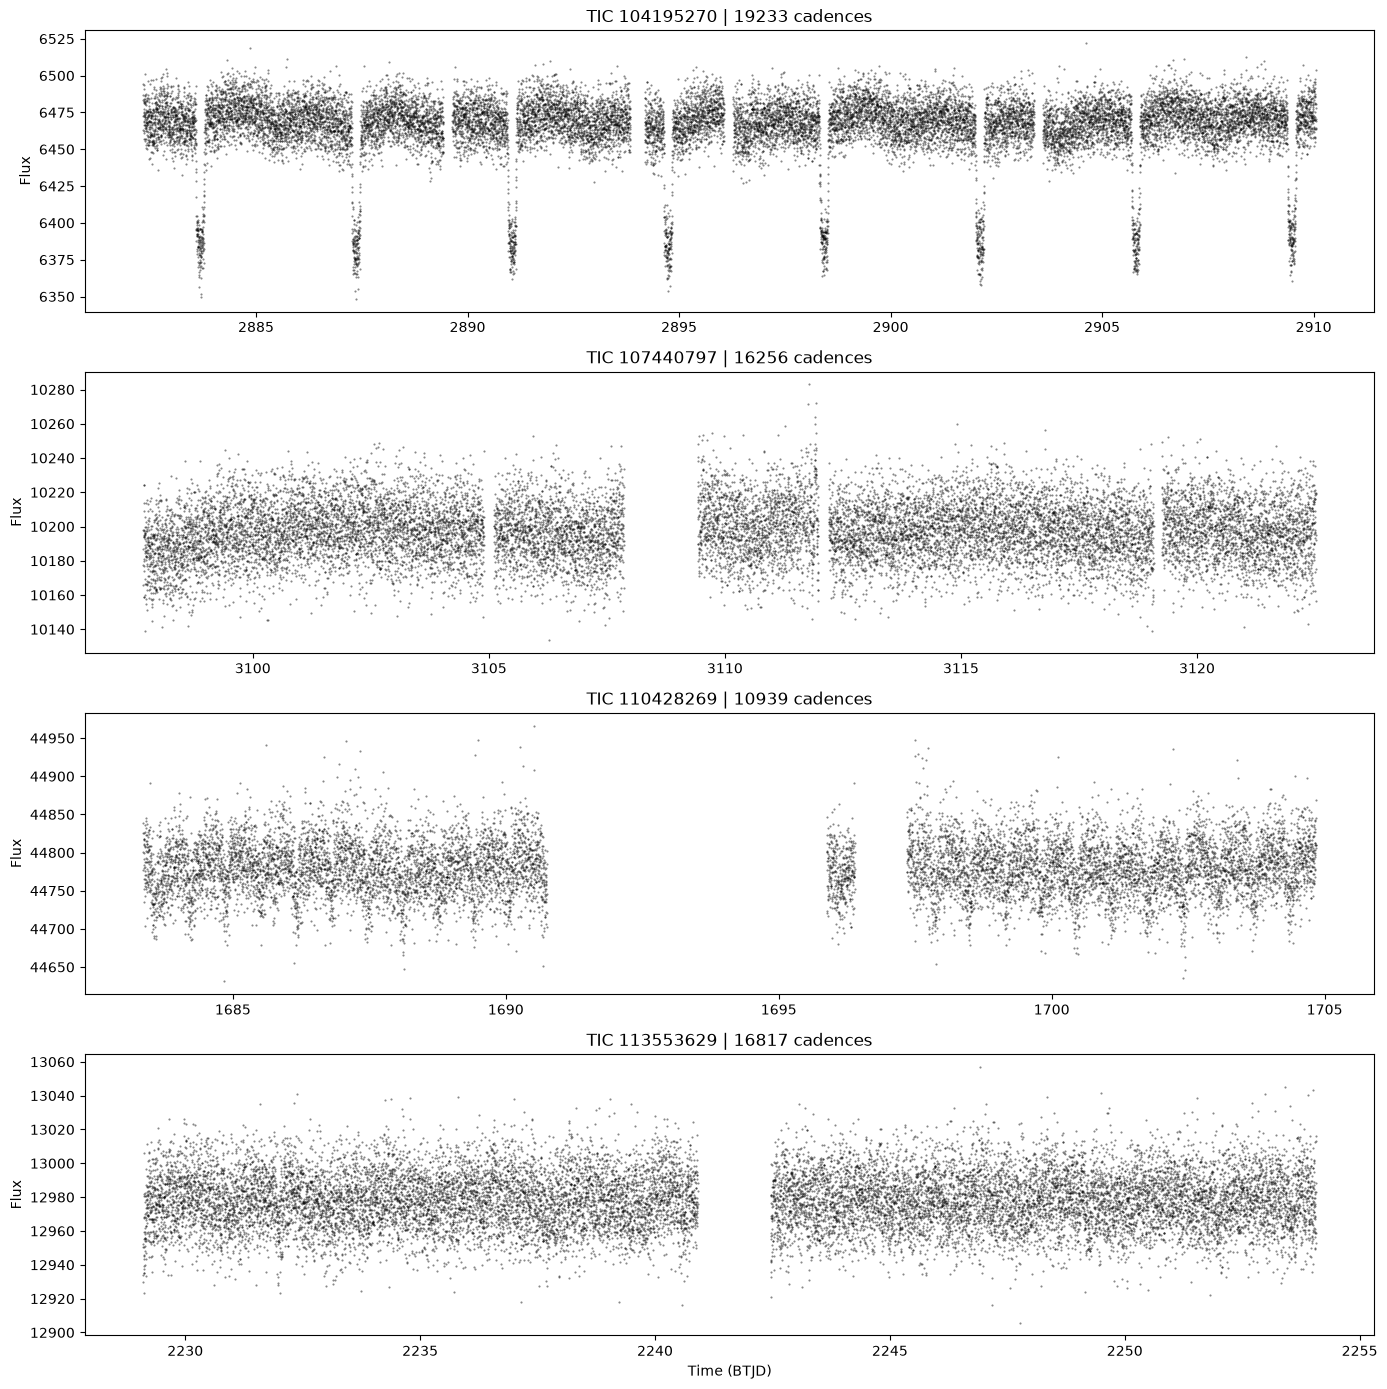

Plot saved to c:\Users\Alivia Hossain\Desktop\exoplanet_detection\Exoplanet_detection\exoplanet-detection\outputs\plots\sample_lightcurves.png


In [21]:
labeled_files = glob.glob(os.path.join(LABELED_DIR, "TIC_*.fits"))
sample_files  = labeled_files[:4] if len(labeled_files) >= 4 else labeled_files

if not sample_files:
    print("No files downloaded yet.")
else:
    fig, axes = plt.subplots(len(sample_files), 1, figsize=(14, 3.5 * len(sample_files)))
    if len(sample_files) == 1:
        axes = [axes]
    for ax, fpath in zip(axes, sample_files):
        try:
            tic_id = os.path.basename(fpath).replace("TIC_", "").replace(".fits", "")
            lc     = lk.read(fpath)
            flux   = lc.pdcsap_flux.value if hasattr(lc, "pdcsap_flux") else lc.flux.value
            t      = lc.time.value
            mask   = np.isfinite(flux) & np.isfinite(t)
            t, flux = t[mask], flux[mask]
            ax.plot(t, flux, "k.", markersize=1, alpha=0.5)
            ax.set_ylabel("Flux")
            ax.set_title(f"TIC {tic_id} | {len(t)} cadences")
        except Exception as e:
            ax.text(0.5, 0.5, f"Cannot plot:\n{e}",
                    ha="center", va="center", transform=ax.transAxes)
    axes[-1].set_xlabel("Time (BTJD)")
    plt.tight_layout()
    plots_dir = os.path.abspath(os.path.join(os.getcwd(), '..', 'outputs', 'plots'))
    os.makedirs(plots_dir, exist_ok=True)
    save_path = os.path.join(plots_dir, 'sample_lightcurves.png')
    plt.savefig(save_path, dpi=150)
    plt.show()
    print(f"Plot saved to {save_path}")


---
## Done!
**Next step: 02_preprocessing.ipynb**